## Overview
This notebook analyzes the North America AFI dataset for the period 1985-2025 and builds a series of maps for return levels, parameter estimates, and model diagnostics. The workflow starts by loading the NetCDF data, defines the spatial domain, and then visualizes how extremes change over time.

In [135]:
import os

## Setup and dependencies

The analysis uses `xarray` for labeled NetCDF data, NumPy and pandas for array and tabular operations, SciPy for statistical support, Matplotlib for plotting, and Cartopy for geographic maps. The additional colormap packages provide consistent color scales across the figures.

In [136]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
from copy import copy


In [137]:
from matplotlib import cm
import cmaps
import matplotlib as mpl
from matplotlib.colors import ListedColormap

In [138]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

In [139]:
# Define colors (names, hex codes, or RGB tuples)
B_colors =["xkcd:purpley","darkblue","blue","xkcd:electric blue","xkcd:lightish blue",\
           "xkcd:sky blue","xkcd:baby blue","xkcd:powder blue","aliceblue"]
# Create a smooth gradient colormap
Blues_map = mcolors.LinearSegmentedColormap.from_list("my_gradient", B_colors)

# Define colors (names, hex codes, or RGB tuples)
R_colors = ["lightyellow","xkcd:cream","yellow","gold",  "darkorange","xkcd:blood orange",\
            "xkcd:red","darkred","xkcd:peachy pink"]
# Create a smooth gradient colormap
Reds_map = mcolors.LinearSegmentedColormap.from_list("my_gradient", R_colors)
BR_map = ListedColormap(np.vstack((Blues_map.resampled(128)(np.linspace(0, 1, 128)),Reds_map.resampled(128)(np.linspace(0, 1, 128)))))

I_colors = ['green','yellow','red','pink']
I_map = mcolors.LinearSegmentedColormap.from_list("my_gradient", I_colors)

# Pvalue colorbar 
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.05, vmax=1)

In [140]:
lon_min = 191 - 360
lon_max = 230 - 360
lat_min = 53
lat_max = 72

cLat = (lat_min + lat_max)/2
cLon = (lon_min + lon_max )/2

## Step 1: Read AFI netcdf file
The next cells load the AFI NetCDF file and extract the key variables used for the maps: return levels, location and scale parameters, shape parameter, and cross-validated diagnostic fields.

In [141]:

B=300

ifile=f'~/data/TXx/Alaska_TXx_GHCND_ij_glostLocSca_extremes_gev_CV_CI300_1979_2025.nc'

ds = xr.open_dataset(ifile)
rl = ds['rl']
location = ds['location']
scale = ds['scale']
shape = ds['shape']
pvalueL = ds['pvalueL']
pvalueS = ds['pvalueS']
AIC = ds['AIC']
BIC = ds['BIC']
location_q = ds['location_q']
scale_q = ds['scale_q']
rl_q = ds['rl_q']
Difflocation_q = ds['Difflocation_q']
Diffscale_q = ds['Diffscale_q']
Diffrl_q = ds['Diffrl_q']
CRPS_cv = ds['CRPS_cv']
DawSeb_cv = ds['DawSeb_cv']
SE_cv = ds['SE_cv']
KS_D_cv = ds['KS_D_cv']
KS_pvalue_cv = ds['KS_pvalue_cv']
CVM_D_cv = ds['CVM_D_cv']
CVM_pvalue_cv = ds['CVM_pvalue_cv']
AIC_cv = ds['AIC_cv']
BIC_cv = ds['BIC_cv']

Tlon = ds.longitude.data
Tlat = ds.latitude.data
return_periods = ds.return_periods.data

units = 'F'

In [142]:
ifile='~/data/TXx/GHCND_TXx_utils_AK.nc'
dsI = xr.open_dataset(ifile)
dsI = dsI.sel(station=ds.station.data)
afi = dsI['TXx']
name = dsI['name']
elevation = dsI['elevation']
longitude = dsI['longitude']
latitude = dsI['latitude']

In [143]:
Tname = [name.split(',')[0] for name in ds['name'].data]

In [144]:

state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

/var/folders/41/jpdddhvx1_bfhbywzg083cy00000gt/T/ipykernel_90601/3446893693.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  Tcolors = cm.get_cmap('nipy_spectral',len(ds['station'])+2)


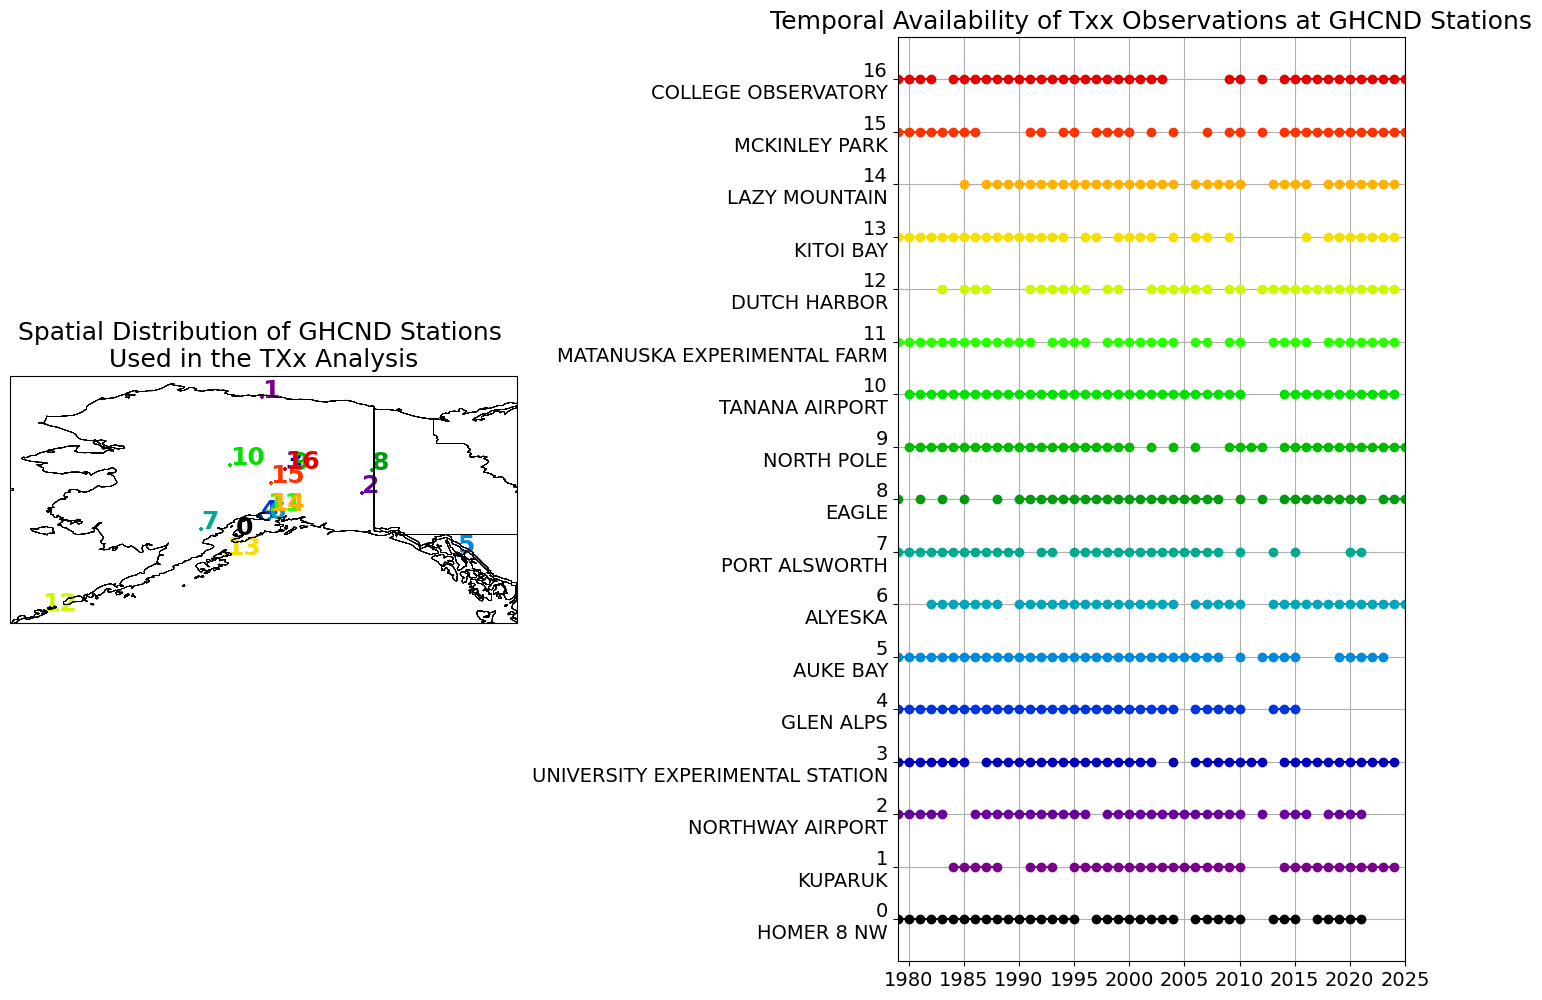

In [145]:
proj=ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(18,12))
ax[0].axis('off')

Tcolors = cm.get_cmap('nipy_spectral',len(ds['station'])+2)
fig.subplots_adjust(hspace=1,wspace=0.75)

ax[0] = fig.add_subplot(1,2,1,projection=proj)
for ij in range(0,len(ds['station'])):
  ilon = Tlon[ij]
  ilat = Tlat[ij]
  istation = ds['station'][ij].data.item()
  iname = ds['name'][ij].data.item().split(',')[0]
  ax[0].scatter(ilon, ilat, marker='+', s=10, color = Tcolors(ij),transform=ccrs.PlateCarree())
  ax[0].text(ilon, ilat, ij, color = Tcolors(ij),fontsize=18, fontweight='bold',transform=ccrs.PlateCarree())
  ax[0].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[0].set_title('Spatial Distribution of GHCND Stations \nUsed in the TXx Analysis',fontsize=18)

  ax[1].plot(dsI.time,ij*xr.where(np.isnan(dsI['TXx'].sel(station=istation))==False,1,np.nan),c=Tcolors(ij),marker='o')
  ax[1].set_title('Temporal Availability of Txx Observations at GHCND Stations',fontsize=18)
ax[0].set_extent((lon_min,lon_max,lat_min,lat_max), crs=ccrs.PlateCarree())
ax[1].set_xlim(1979,2025)
ax[1].set_xticks(np.arange(1980,2025+5,5))
ax[1].set_xticklabels(np.arange(1980,2025+5,5),fontsize=14)
ax[1].set_yticks(np.arange(0,len(ds.station)))
ax[1].set_yticklabels([f'{ax[1].get_yticks()[i]}\n{Tname[i]}' for i in range(len(Tname))],fontsize=14)
ax[1].grid()
#ax[0].axis('off')
plt.show()

*GHCND stations used in the Alaska AFI analysis and the temporal availability of observations. The left panel shows the geographic distribution of the selected GHCND stations, labeled by station identifier. Stations were selected based on a data completeness criterion requiring at least 70% availability of annual observations during the 1980-2025 period, ensuring adequate coverage for model evaluation and comparison. The right panel displays the temporal availability of AFI observations for each station from 1980 to 2024, where each point represents a year with available observations.
Although station selection was based on data availability during 1980-2025, the GEV analyses were performed using the complete observational record available at each station, including observations collected prior to 1980. For the station-based GEV fits, the initial values of the location, scale, and shape parameters were obtained from ERA5-derived parameter estimates averaged over time, providing physically consistent starting points for the optimization procedure. Together, these panels illustrate the spatial distribution, temporal coverage, and methodological basis of the station dataset used for extreme value analysis and validation.*

/var/folders/41/jpdddhvx1_bfhbywzg083cy00000gt/T/ipykernel_90601/3473811782.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  Tcolors = cm.get_cmap('nipy_spectral',len(ds['station'])+2)


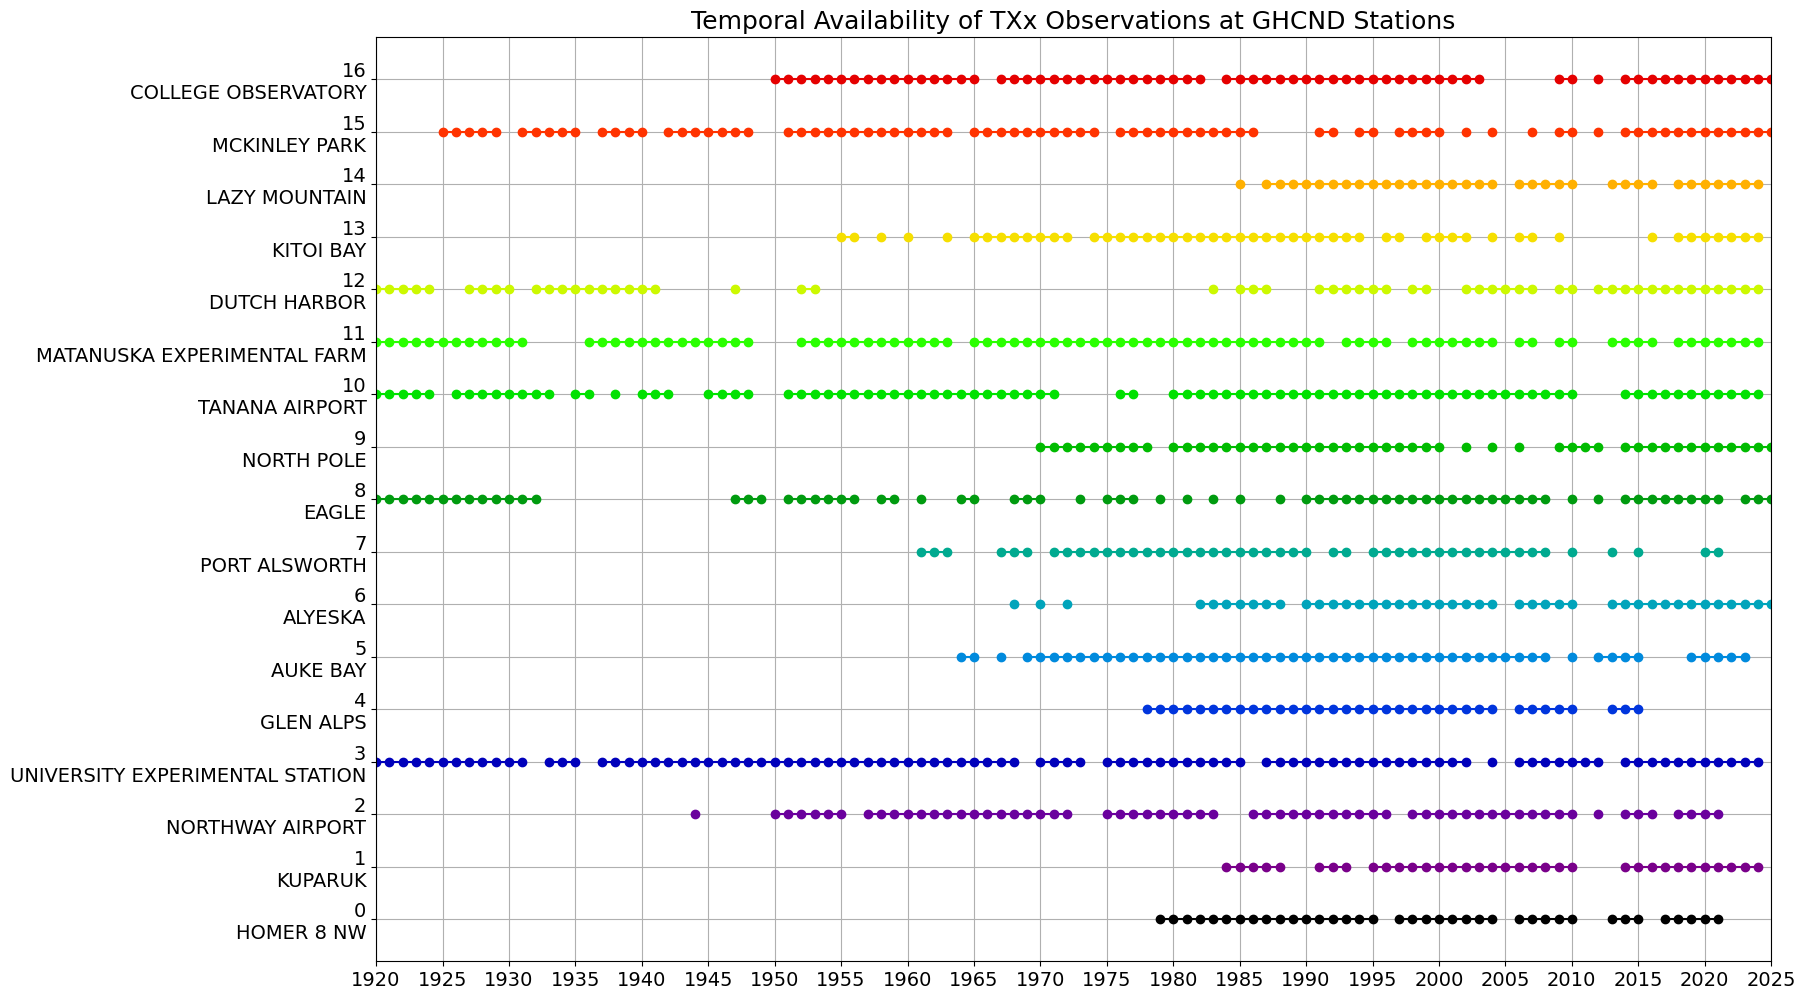

In [146]:
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(18,12))

Tcolors = cm.get_cmap('nipy_spectral',len(ds['station'])+2)
fig.subplots_adjust(hspace=1,wspace=0.75)

for ij in range(0,len(ds['station'])):
  ilon = Tlon[ij]
  ilat = Tlat[ij]
  istation = ds['station'][ij].data.item()
  iname = ds['name'][ij].data.item().split(',')[0]
  ax.plot(dsI.time,ij*xr.where(np.isnan(dsI['TXx'].sel(station=istation))==False,1,np.nan),c=Tcolors(ij),marker='o')
  ax.set_title('Temporal Availability of TXx Observations at GHCND Stations',fontsize=18)
ax.set_xlim(1920,2025)
ax.set_xticks(np.arange(1920,2025+5,5))
ax.set_xticklabels(np.arange(1920,2025+5,5),fontsize=14)
ax.set_yticks(np.arange(0,len(ds.station)))
ax.set_yticklabels([f'{ax.get_yticks()[i]}\n{Tname[i]}' for i in range(len(Tname))],fontsize=14)
ax.grid()
#ax[0].axis('off')
plt.show()

In [147]:
ifile=f'~/data/TXx/Alaska_TXx_ij_glostLocSca_extremes_gev_CV_1979_2025.nc'

dsERA5 = xr.open_dataset(ifile)

dsERA5 = dsERA5.sel(lon=slice(lon_min+360,lon_max+360),lat=slice(lat_min,lat_max))
rlERA5 = dsERA5['rl']
locationERA5 = dsERA5['location']
scaleERA5 = dsERA5['scale']
shapeERA5 = dsERA5['shape']
pvalueLERA5 = dsERA5['pvalueL']
pvalueSERA5 = dsERA5['pvalueS']
CRPS_cvERA5 = dsERA5['CRPS_cv']
DawSeb_cvERA5 = dsERA5['DawSeb_cv']
SE_cvERA5 = dsERA5['SE_cv']
KS_D_cvERA5 = dsERA5['KS_D_cv']
KS_pvalue_cvERA5 = dsERA5['KS_pvalue_cv']
CVM_D_cvERA5 = dsERA5['CVM_D_cv']
CVM_pvalue_cvERA5 = dsERA5['CVM_pvalue_cv']

#location_qERA5 = dsERA5['location_q']
#scale_qERA5 = dsERA5['scale_q']
#rl_qERA5 = dsERA5['rl_q']
#Difflocation_qERA5 = dsERA5['Difflocation_q']
#Diffscale_qERA5 = dsERA5['Diffscale_q']
#Diffrl_qERA5 = dsERA5['Diffrl_q']

## Step 2: Define plotting settings

These settings set the map extents, return periods, and contour levels used throughout the figures below.


In [148]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [149]:
Tyears=[1951,1960,1970,1980,1990,2000,2010,2020,2025]
Tyears=[1979,2025]
AEP = [1/irp for irp in return_periods]

## Step 3: Figure descriptions

The next figures show the fitted return levels and their changes over time for several return periods. Each map is designed to highlight spatial differences in extreme-event magnitude across North America.

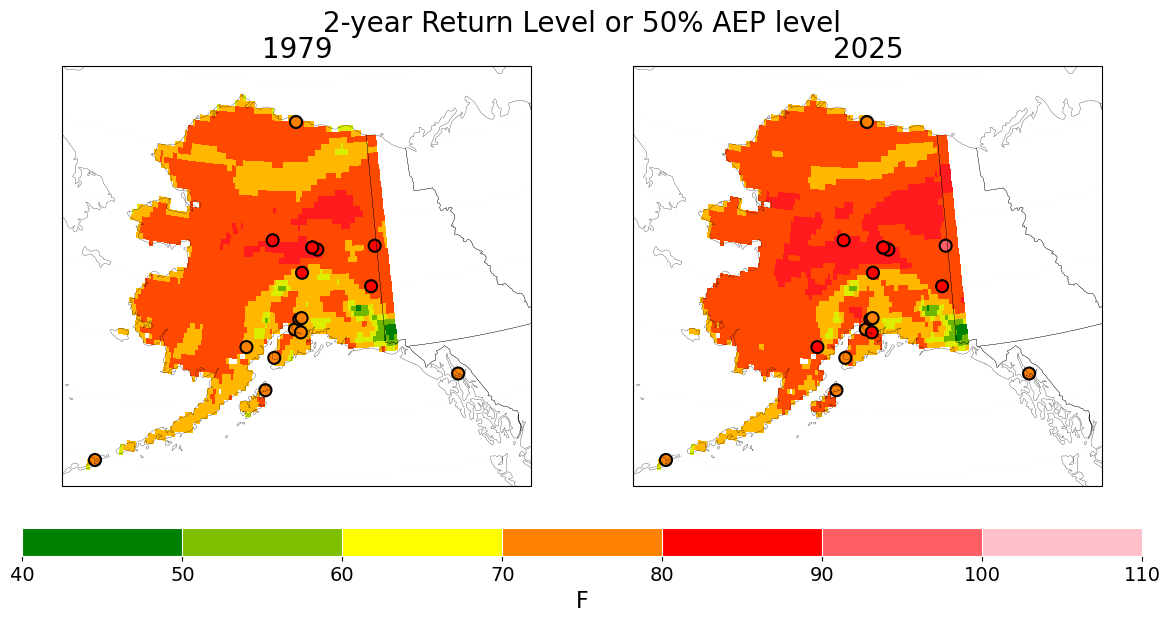

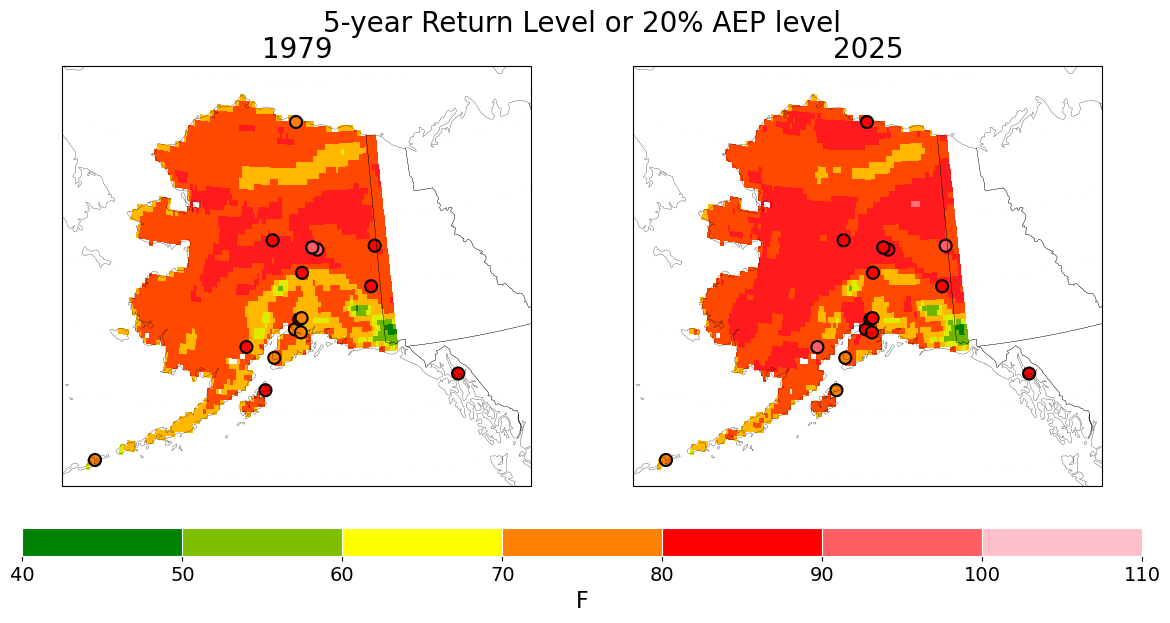

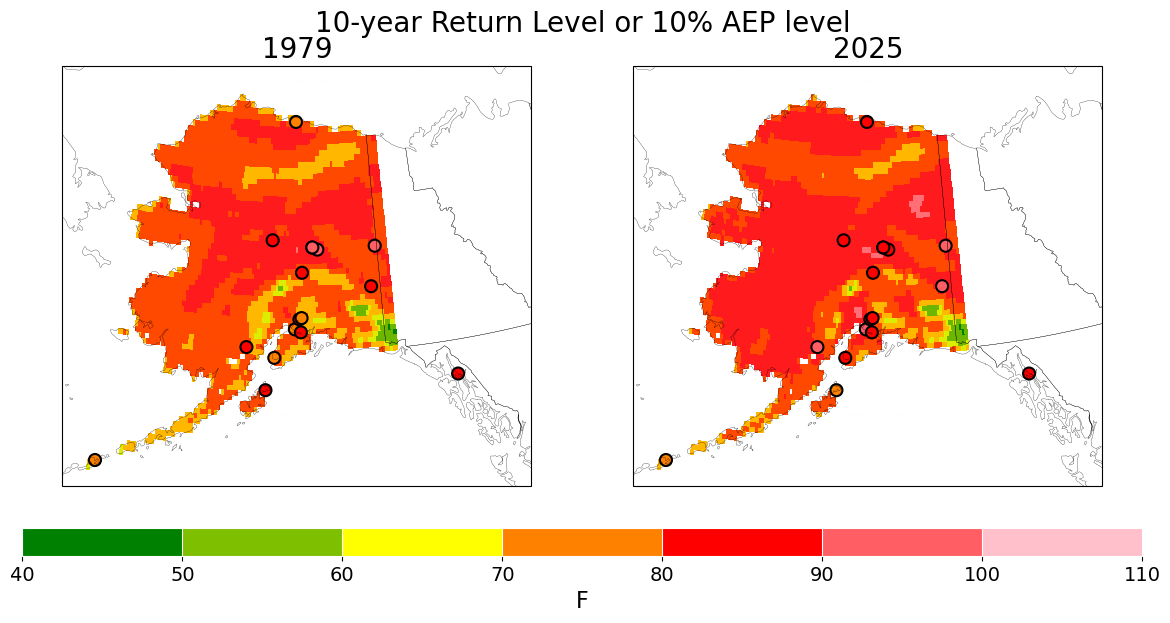

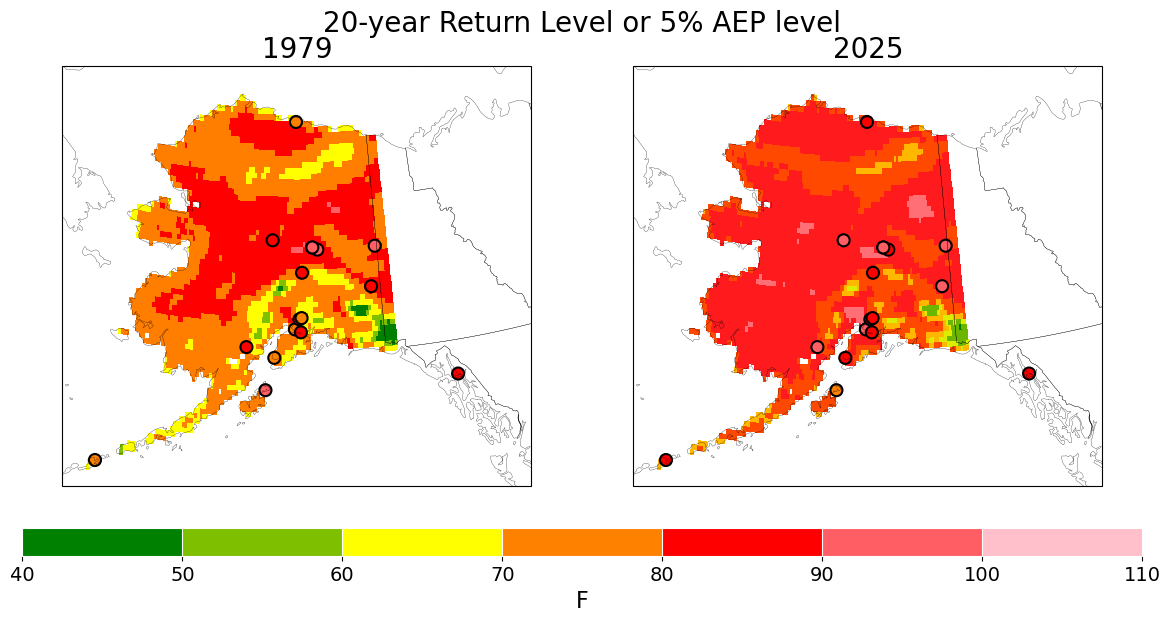

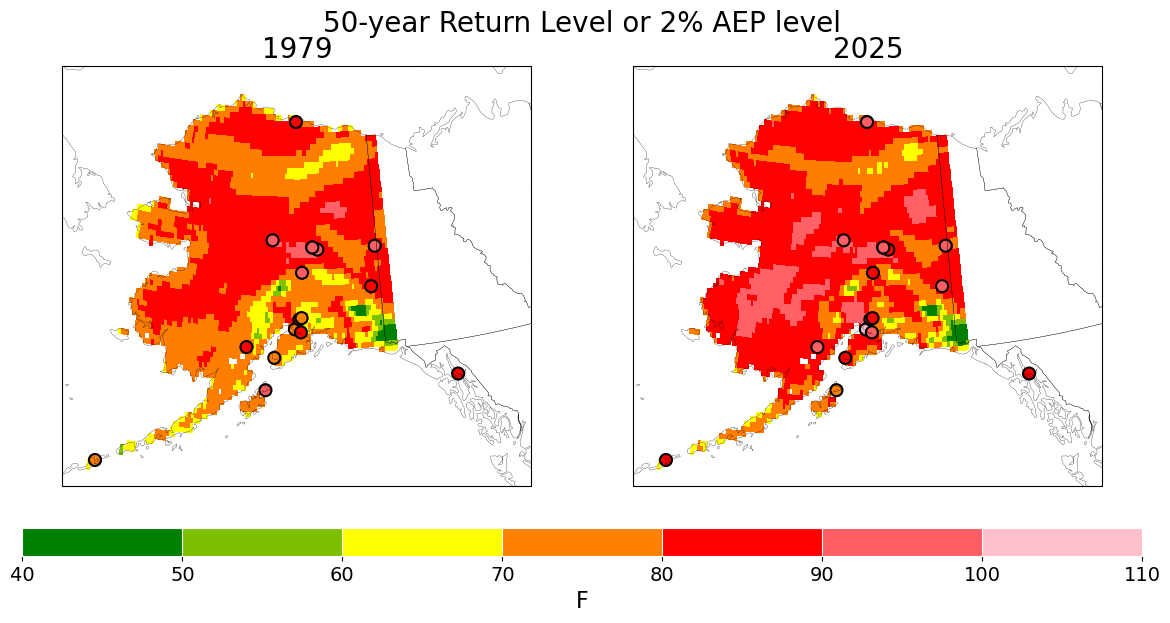

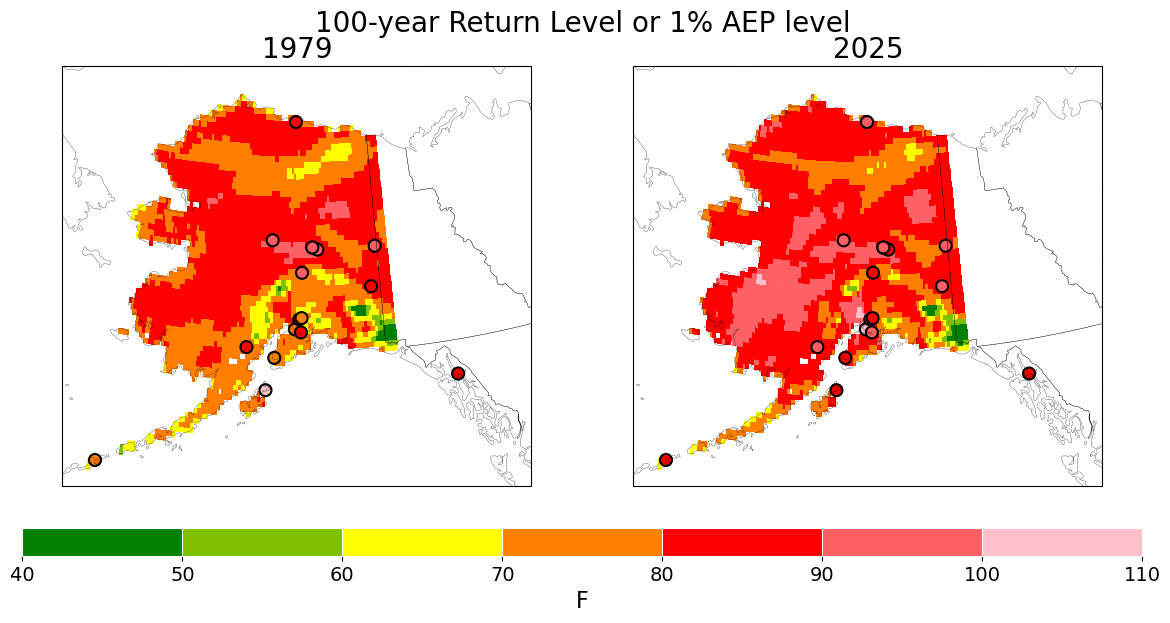

In [150]:

proj=ccrs.PlateCarree()
proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

clevs=np.arange(40,120,10)
cmap=I_map
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)
for irp in range(0,len(return_periods)):
  fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,7),subplot_kw={'projection':proj})

  plt.subplots_adjust(bottom=0.3,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)
  ax = ax.flatten()

  for ix in range(0,len(Tyears)):
    rlERA5.isel(return_periods=irp).sel(time=Tyears[ix]).\
    plot.pcolormesh(ax=ax[ix],cmap=cmap,levels=clevs,transform=ccrs.PlateCarree(),add_colorbar=False)
    cc = ax[ix].scatter(Tlon,Tlat,c=rl.sel(return_periods=return_periods[irp],time=Tyears[ix]),s=75,cmap=cmap,norm=norm,\
          transform=ccrs.PlateCarree(),edgecolor='k',linewidth=1.5)
    ax[ix].set_title(f'{Tyears[ix]}',fontsize=20)  

  for ix in range(0,len(ax)):
    ####
    grd = ax[ix].gridlines(
      draw_labels=False, 
      color='gray', alpha=0.01, linestyle='--')
    grd.top_labels = False   # Disable top labels
    grd.right_labels = False # Disable right labels. 
    ax[ix].set_extent((lon_min,lon_max,lat_min,lat_max), crs=proj_data)
    ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.2)

  #
  ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])

  cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',drawedges=True)
  cbar.ax.tick_params(labelsize=14)  
  cbar.set_label(label=f'{units}',fontsize=16)  
  cbar.outline.set_edgecolor('w')
  cbar.dividers.set_edgecolor('w')
  cbar.dividers.set_linewidth(0.8)

  plt.suptitle(f'{return_periods[irp]}-year Return Level or {AEP[irp]*100:.0f}% AEP level',fontsize=20)  

*Return-level maps:
These panels show the estimated return level/annual exceedance probability for selected return periods at two reference years (1985, 2025), illustrating how the intensity of extreme events varies geographically and temporally across Alaska. Shaded contours show return-level estimates derived from the ERA5 reanalysis, while colored circles indicate corresponding estimates from GHCND station observations, enabling a comparison between gridded and station-based datasets.*


/var/folders/41/jpdddhvx1_bfhbywzg083cy00000gt/T/ipykernel_90601/1234559053.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlBu_r',len(clevs))


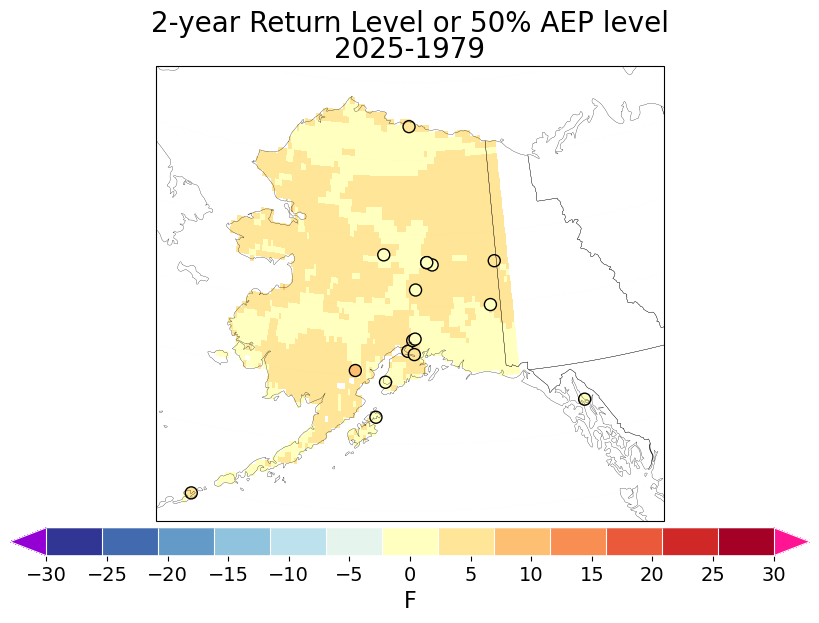

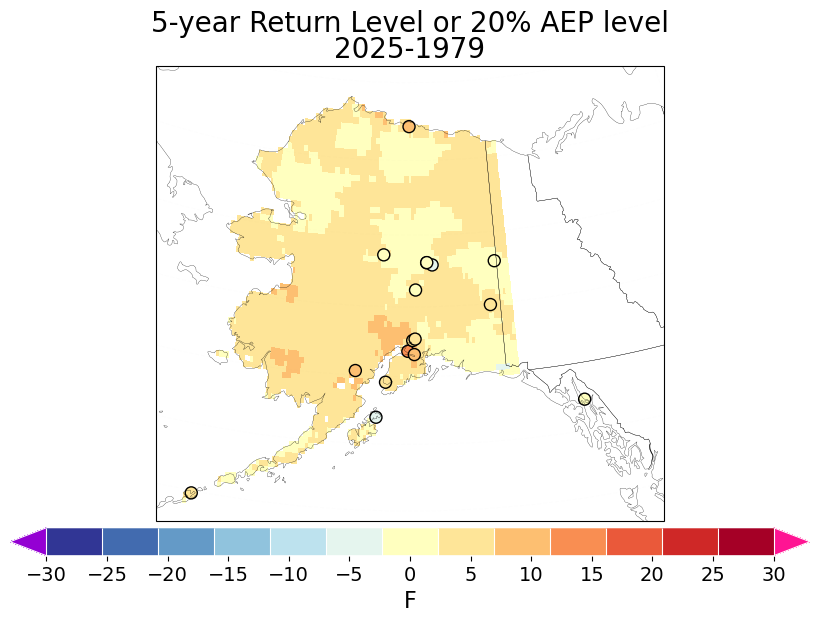

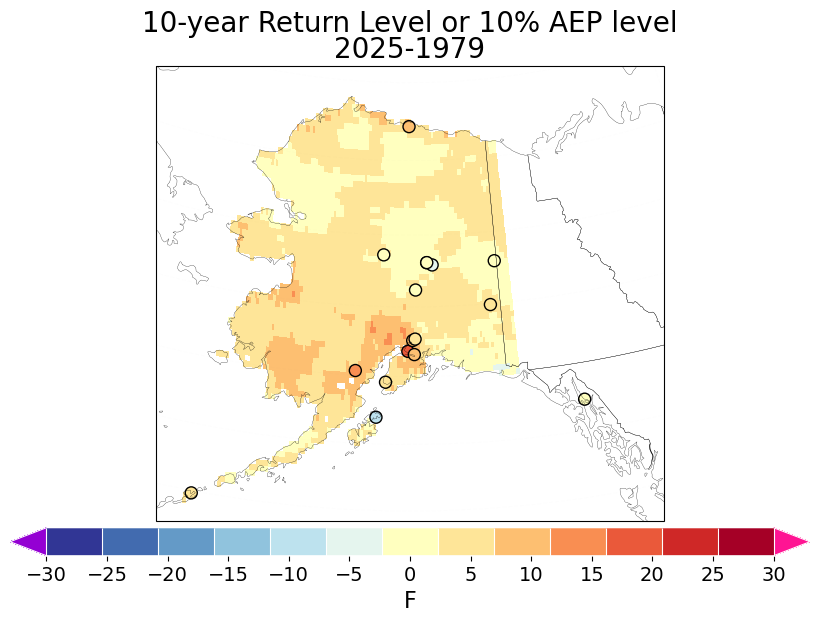

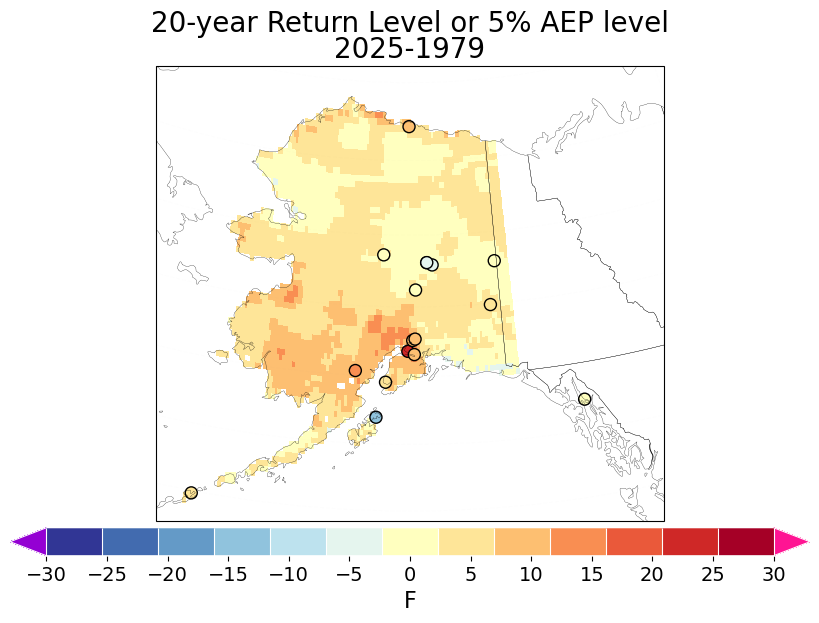

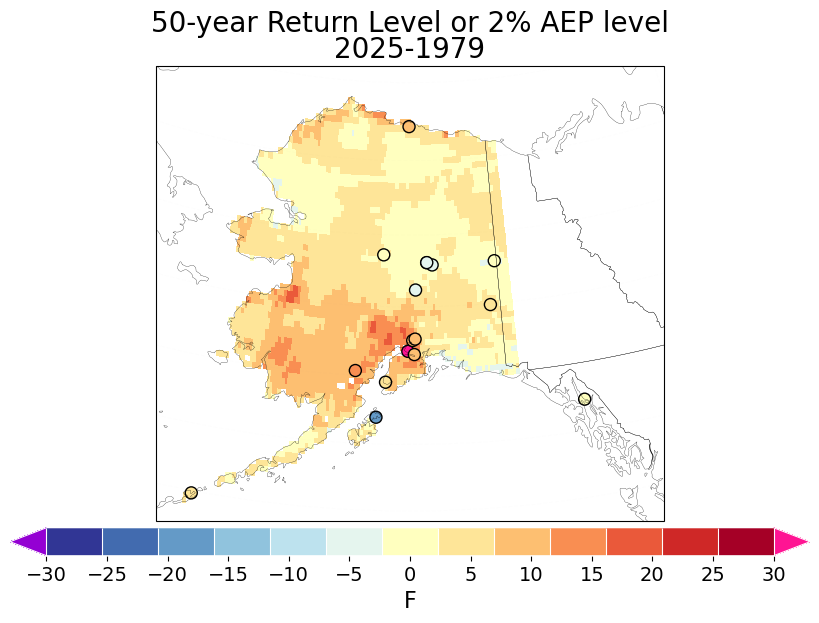

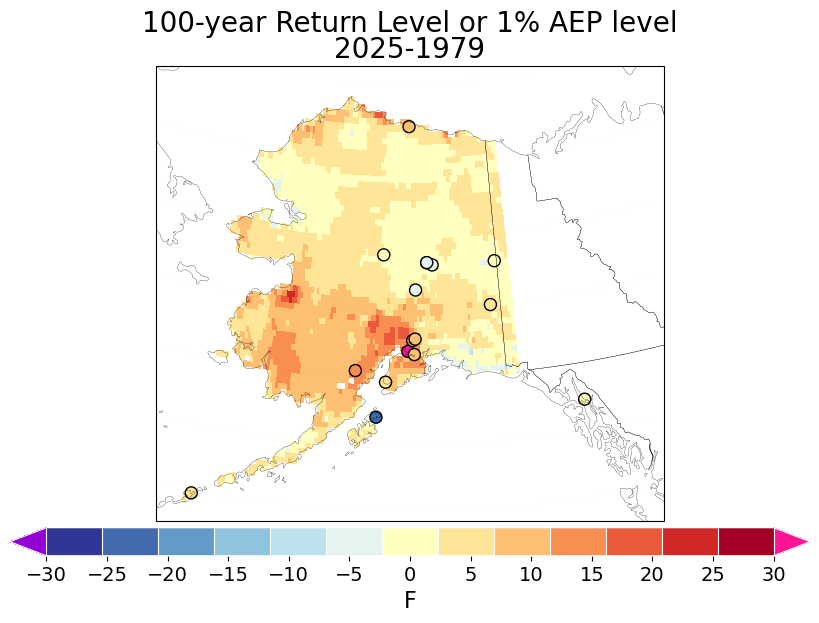

In [151]:
proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

clevs=np.arange(-30,35,5)
cmap = cm.get_cmap('RdYlBu_r',len(clevs))
cmap.set_under('darkviolet')
cmap.set_over('deeppink')
norm = mcolors.TwoSlopeNorm(vcenter=0,vmin=clevs[0],vmax=-clevs[0])

for irp in range(0,len(return_periods)):
  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,7),subplot_kw={'projection':proj})
  plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)
  (rlERA5.isel(return_periods=irp).sel(time=Tyears[-1])-rlERA5.isel(return_periods=irp).sel(time=Tyears[0])).\
    plot.pcolormesh(ax=ax,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,add_colorbar=False)
  cc = ax.scatter(Tlon,Tlat,c=(rl.isel(return_periods=irp).sel(time=Tyears[-1])-rl.isel(return_periods=irp).sel(time=Tyears[0])),\
          s=75,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),edgecolor='k')
  ax.set_title(f'{Tyears[-1]}-{Tyears[0]}',fontsize=20)  
  ##

  ####
  grd = ax.gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax.set_extent((lon_min,lon_max,lat_min,lat_max), crs=proj_data)
  ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.2)

  #
  ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
  cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',extend='both',drawedges=True)
  cbar.set_ticks(clevs[:])
  cbar.ax.tick_params(labelsize=14)  
  cbar.set_label(label=f'{units}',fontsize=16)  
  cbar.outline.set_edgecolor('w')
  cbar.dividers.set_edgecolor('w')
  cbar.dividers.set_linewidth(0.8)

  plt.suptitle(f'{return_periods[irp]}-year Return Level or {AEP[irp]*100:.0f}% AEP level',fontsize=20) 

*Change between two time periods:
Change in the estimated return level/annual exceedance probability for selected return periods between 2025 and 1985 across Alaska, expressed as 2025 minus 1985 (°C-days). Shaded grid cells represent differences derived from the ERA5 reanalysis, while overlaid circles show corresponding changes estimated from GHCND station observations. Negative values (warm colors) indicate a decrease in the return level over time, whereas positive values (cool colors) indicate an increase.*


In [152]:

## Build colorbar
from matplotlib import cm
clevsa=np.arange(0.05,1.01,0.01)
clevsb=np.arange(0,0.05,0.001)
clevs_pv=np.concatenate((clevsb,clevsa))
cmap = cm.get_cmap('Purples',len(clevsa)+20)
cmaplist = [cmap(i) for i in range(20,cmap.N)]
cmap2 = cm.get_cmap('YlGn_r', len(clevsb)+5)
cmaplist2 = [cmap2(i) for i in range(0,cmap2.N-5)]

cmap_pv = mcolors.LinearSegmentedColormap.from_list('Custom cmap',\
                cmaplist2+cmaplist, len(cmaplist2)+len(cmaplist))

norm_pv = mcolors.BoundaryNorm(boundaries=clevs_pv, ncolors=cmap_pv.N)
               

/var/folders/41/jpdddhvx1_bfhbywzg083cy00000gt/T/ipykernel_90601/1989384026.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Purples',len(clevsa)+20)
/var/folders/41/jpdddhvx1_bfhbywzg083cy00000gt/T/ipykernel_90601/1989384026.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('YlGn_r', len(clevsb)+5)


Text(0.5, 0.98, 'p-value Non Stationnary hypothesis')

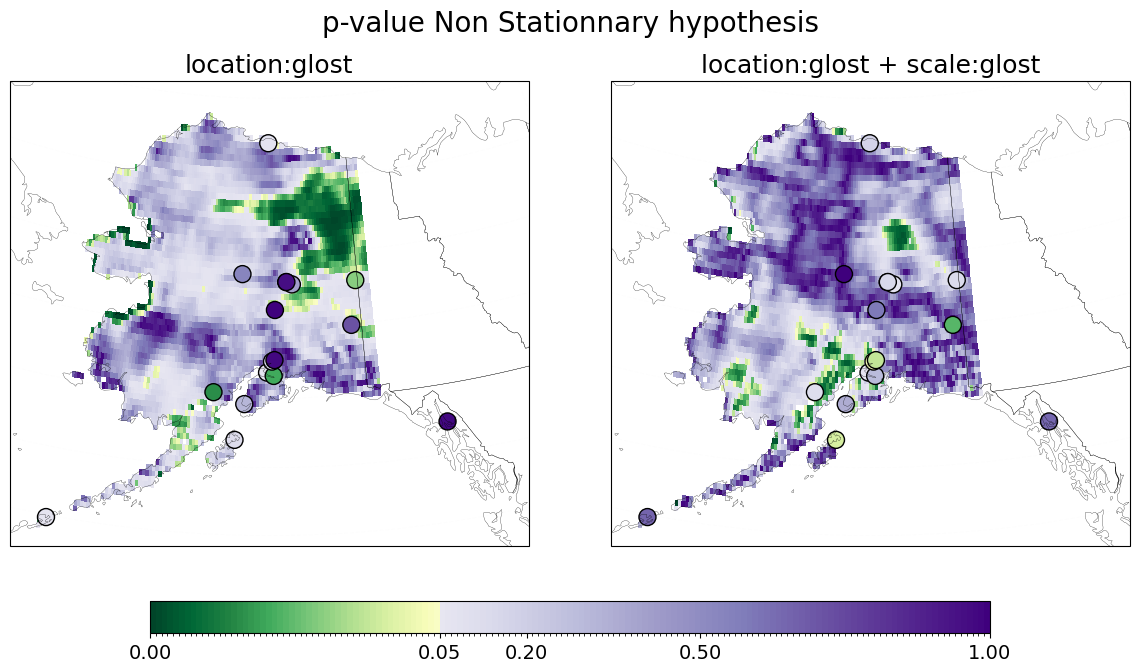

In [153]:
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.95,hspace=0.04,wspace=0.16)
ax = ax.flatten()
cc = pvalueLERA5.plot.pcolormesh(ax=ax[0],cmap=cmap_pv,norm=norm_pv,transform=ccrs.PlateCarree(),add_colorbar=False)
cc = ax[0].scatter(Tlon,Tlat,c=pvalueL,\
          s=150,cmap=cmap_pv,norm=norm_pv,transform=ccrs.PlateCarree(),edgecolor='k')
ax[0].set_title(f'location:glost',fontsize=18)  
cc = pvalueSERA5.plot.pcolormesh(ax=ax[1],cmap=cmap_pv,norm=norm_pv,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[1].scatter(Tlon,Tlat,c=pvalueS,\
          s=150,cmap=cmap_pv,norm=norm_pv,transform=ccrs.PlateCarree(),edgecolor='k')
ax[1].set_title(f'location:glost + scale:glost',fontsize=18)  

for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].set_extent((lon_min,lon_max,lat_min,lat_max), crs=proj_data)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.2)

#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=[0,0.05,0.2,0.5,1])
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)
#

plt.suptitle(f'p-value Non Stationnary hypothesis',fontsize=20)  

*P-value maps for non-stationarity tests (location and location + scale). Green shading identifies regions where the mean p-value is less than 0.05, indicating statistically significant non-stationarity at the 95% confidence level. Lower p-values reflect stronger evidence for rejecting the stationary-hypothesis null.*

Text(0.5, 0.98, 'Location parameter')

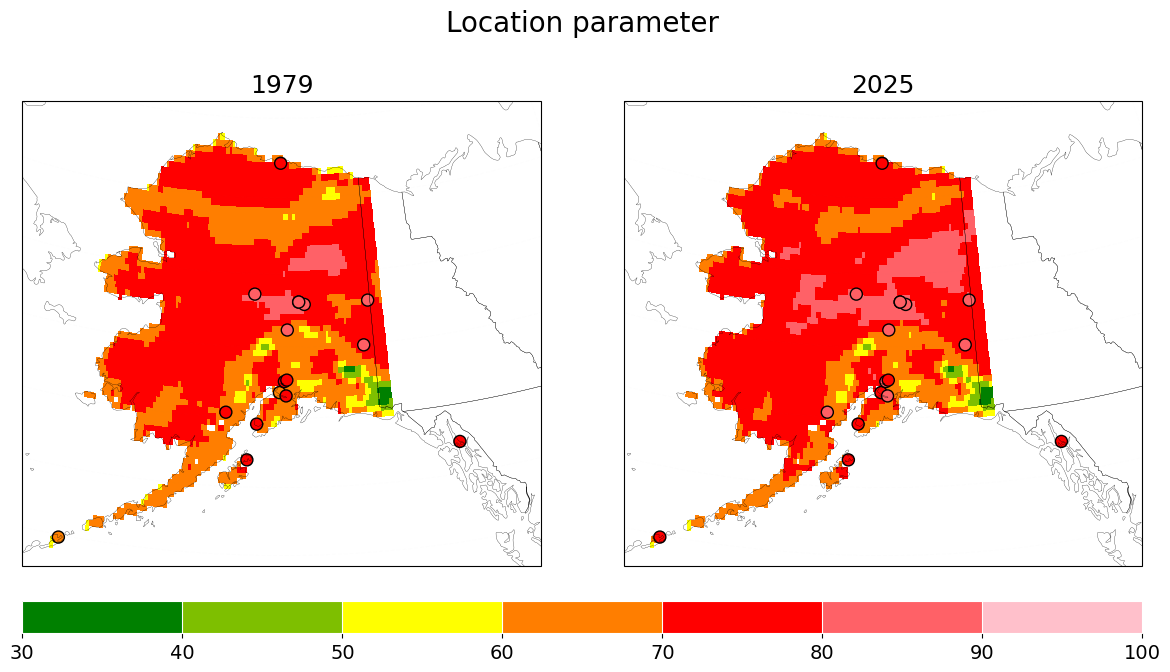

In [154]:
clevs = np.arange(30,110,10)
cmap = plt.get_cmap(I_map,len(clevs)).copy()
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)

proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = locationERA5.sel(time=Tyears[0]).plot.pcolormesh(ax=ax[0],cmap=cmap,levels=clevs,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[0].scatter(Tlon,Tlat,c=location.sel(time=Tyears[0]),s=75,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),edgecolor='k')
ax[0].set_title(Tyears[0],fontsize=18)    
locationERA5.sel(time=Tyears[-1]).plot.pcolormesh(ax=ax[1],cmap=cmap,levels=clevs,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[1].scatter(Tlon,Tlat,c=location.sel(time=Tyears[-1]),s=75,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),edgecolor='k')
ax[1].set_title(Tyears[-1],fontsize=18)    

####
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].set_extent((lon_min,lon_max,lat_min,lat_max), crs=proj_data)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.2)

#
#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[:],drawedges=True)
cbar.set_label(label='',fontsize=16)
cbar.ax.tick_params(labelsize=14)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
plt.suptitle(f'Location parameter',fontsize=20)  

*Spatial distribution of the GEV location parameter across Alaska for 1985 (left) and 2025 (right). The shaded fields represent estimates derived from the ERA5 reanalysis, while the circles indicate corresponding estimates from GHCND station observations. The maps show the geographic variability of the location parameter and its temporal evolution, with generally higher values across northern Alaska and lower values along coastal and southern regions.*

/var/folders/41/jpdddhvx1_bfhbywzg083cy00000gt/T/ipykernel_90601/3727912925.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlBu_r',len(clevs))


Text(0.5, 0.98, 'Location parameter')

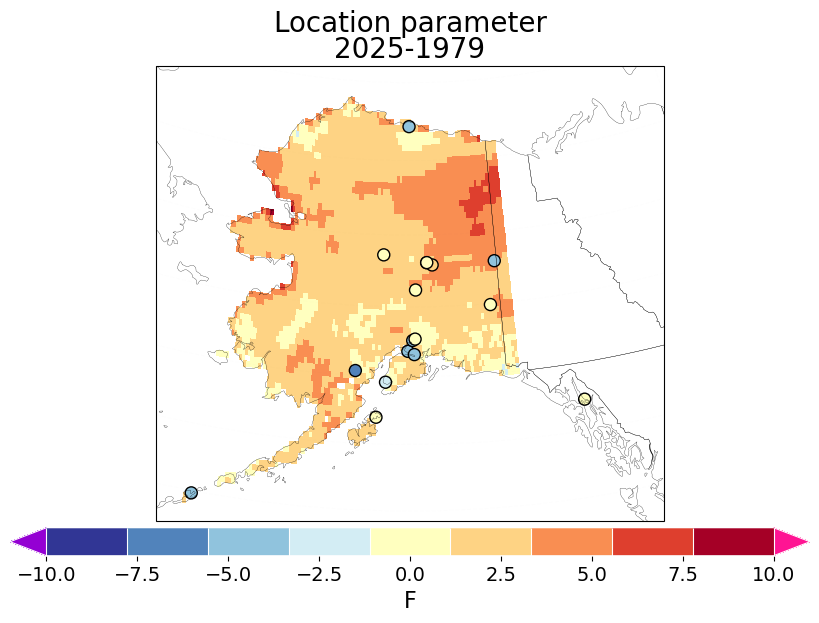

In [155]:
proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

clevs=np.arange(-10,12.5,2.5)
cmap = cm.get_cmap('RdYlBu_r',len(clevs))
cmap.set_under('darkviolet')
cmap.set_over('deeppink')
norm = mcolors.TwoSlopeNorm(vcenter=0,vmin=clevs[0],vmax=-clevs[0])

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)

cc = (locationERA5.sel(time=Tyears[-1])-locationERA5.sel(time=Tyears[0])).\
  plot.pcolormesh(ax=ax,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,add_colorbar=False)
ax.scatter(Tlon,Tlat,c=(location.sel(time=Tyears[0])-location.sel(time=Tyears[-1])),s=75,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),edgecolor='k')
  
ax.set_title(f'{Tyears[-1]}-{Tyears[0]}',fontsize=20)  
##

####
grd = ax.gridlines(
  draw_labels=False, 
  color='gray', alpha=0.01, linestyle='--')
grd.top_labels = False   # Disable top labels
grd.right_labels = False # Disable right labels. 
ax.set_extent((lon_min,lon_max,lat_min,lat_max), crs=proj_data)
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.2)

#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',extend='both',drawedges=True)
cbar.set_ticks(clevs[:])
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'{units}',fontsize=16)
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
plt.suptitle(f'Location parameter',fontsize=20)  

*Change in the GEV location parameter between 1985 and 2025 across Alaska, expressed as 2025 minus 1985 (°C-days). 
The shaded grid cells represent differences estimated from the ERA5 reanalysis, while the overlaid circles show corresponding changes derived from GHCND station observations. Negative values (yellow to red shades) indicate a decrease in the location parameter over time, whereas positive values (light to dark blue shades) indicate an increase. The results show predominantly negative changes across most of Alaska, with the largest decreases occurring in northern regions, suggesting a reduction in the central tendency of extreme-event magnitudes over the study period.*

Text(0.5, 0.98, 'Scale parameter')

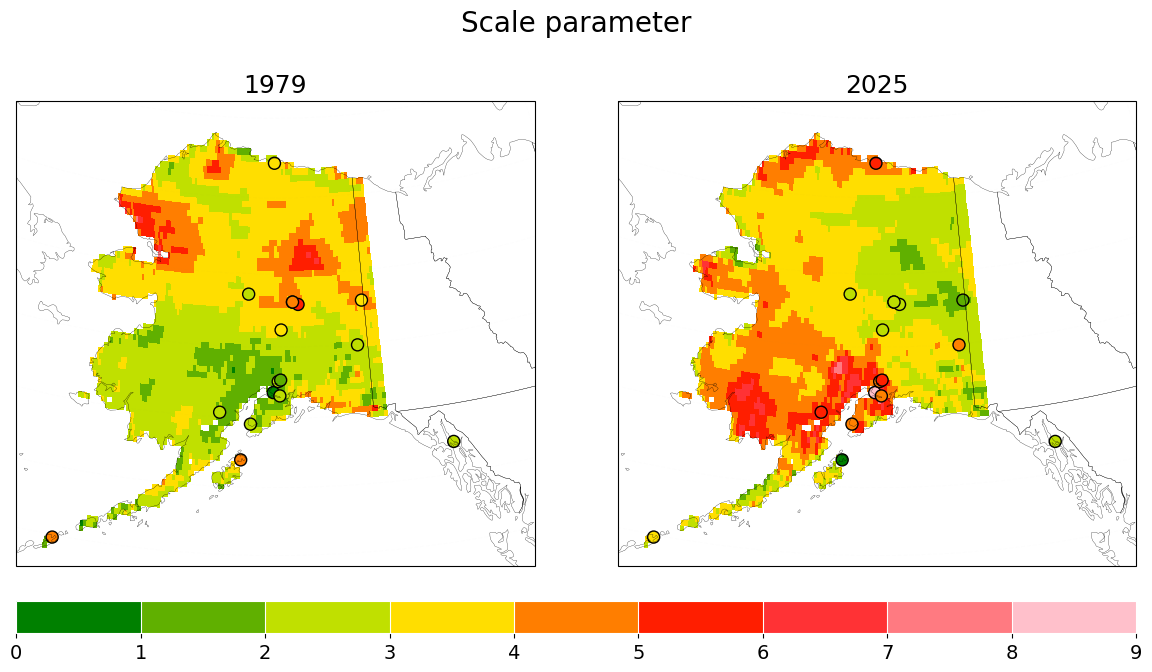

In [156]:
clevs = np.arange(0,10,1)
cmap = plt.get_cmap(I_map,len(clevs)).copy()
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)

proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = scaleERA5.sel(time=Tyears[0]).plot.pcolormesh(ax=ax[0],cmap=cmap,levels=clevs,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[0].scatter(Tlon,Tlat,c=scale.sel(time=Tyears[0]),s=75,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),edgecolor='k')
ax[0].set_title(Tyears[0],fontsize=18)    

scaleERA5.sel(time=Tyears[-1]).plot.pcolormesh(ax=ax[1],cmap=cmap,levels=clevs,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[1].scatter(Tlon,Tlat,c=scale.sel(time=Tyears[-1]),s=75,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),edgecolor='k')
ax[1].set_title(Tyears[-1],fontsize=18)    

####
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].set_extent((lon_min,lon_max,lat_min,lat_max), crs=proj_data)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.2)

#
#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[:],drawedges=True)
cbar.set_label(label='',fontsize=16)
cbar.ax.tick_params(labelsize=14)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
plt.suptitle(f'Scale parameter',fontsize=20)  

*Spatial distribution of the GEV scale parameter across Alaska for 1985 (left) and 2025 (right). The shaded fields represent scale parameter estimates derived from the ERA5 reanalysis, while the colored circles indicate corresponding estimates from GHCND station observations. The scale parameter describes the variability or spread of extreme-event magnitudes, with higher values (red to pink) indicating greater variability and lower values (green to yellow) indicating more consistent extremes. The maps reveal substantial spatial heterogeneity, with larger scale parameter values across northern and interior Alaska and lower values along coastal and southern regions. Comparison between the two years suggests a general reduction in the variability of extremes across much of the state by 2025.*

/var/folders/41/jpdddhvx1_bfhbywzg083cy00000gt/T/ipykernel_90601/1791841908.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlBu_r',len(clevs))


Text(0.5, 0.98, 'Shape parameter')

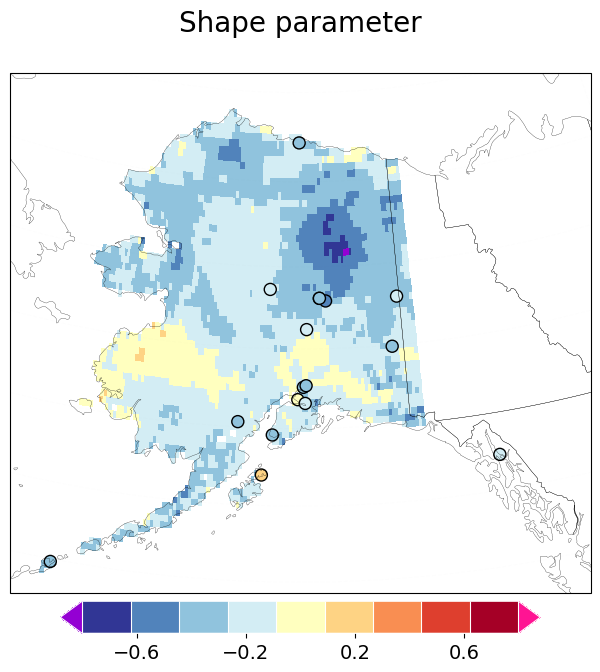

In [157]:
clevs = np.arange(-0.8,1.,0.2)

cmap = cm.get_cmap('RdYlBu_r',len(clevs))
cmap.set_under('darkviolet')
cmap.set_over('deeppink')
norm = mcolors.TwoSlopeNorm(vcenter=0,vmin=clevs[0],vmax=-clevs[0])

proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(8,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = shapeERA5.sel(time=Tyears[0]).plot.pcolormesh(ax=ax,cmap=cmap,vmin=clevs[0],vmax=clevs[-1],transform=ccrs.PlateCarree(),add_colorbar=False)
cc = ax.scatter(Tlon,Tlat,c=shape.sel(time=Tyears[0]),s=75,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),edgecolor='k')
ax.set_title('',fontsize=18) 
####

####
grd = ax.gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
grd.top_labels = False   # Disable top labels
grd.right_labels = False # Disable right labels. 
ax.set_extent((lon_min,lon_max,lat_min,lat_max), crs=proj_data)
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.2)
#
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[1::2],drawedges=True,extend='both')
cbar.ax.tick_params(labelsize=14)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
plt.suptitle(f'Shape parameter',fontsize=20)  

*Spatial distribution of the GEV shape parameter across Alaska. The shaded field represents shape parameter estimates derived from the ERA5 reanalysis, while the colored circles indicate corresponding estimates from GHCND station observations. The shape parameter characterizes the behavior of the distribution tail and therefore influences the probability of the most extreme events. Negative values (blue shades) indicate a bounded upper tail, whereas positive values (yellow to red shades) indicate a heavier tail and a greater likelihood of exceptionally large extremes. Across most of Alaska, the shape parameter is negative to near zero, suggesting that the distribution of extreme events is generally bounded, with localized variations evident in both the ERA5 and station-based estimates.*

/var/folders/41/jpdddhvx1_bfhbywzg083cy00000gt/T/ipykernel_90601/703962193.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('turbo',len(clevs)-1)
/var/folders/41/jpdddhvx1_bfhbywzg083cy00000gt/T/ipykernel_90601/703962193.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('turbo',len(clevs)-1)
/var/folders/41/jpdddhvx1_bfhbywzg083cy00000gt/T/ipykernel_90601/703962193.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c

Text(0.5, 0.98, 'Tests averaged in Time')

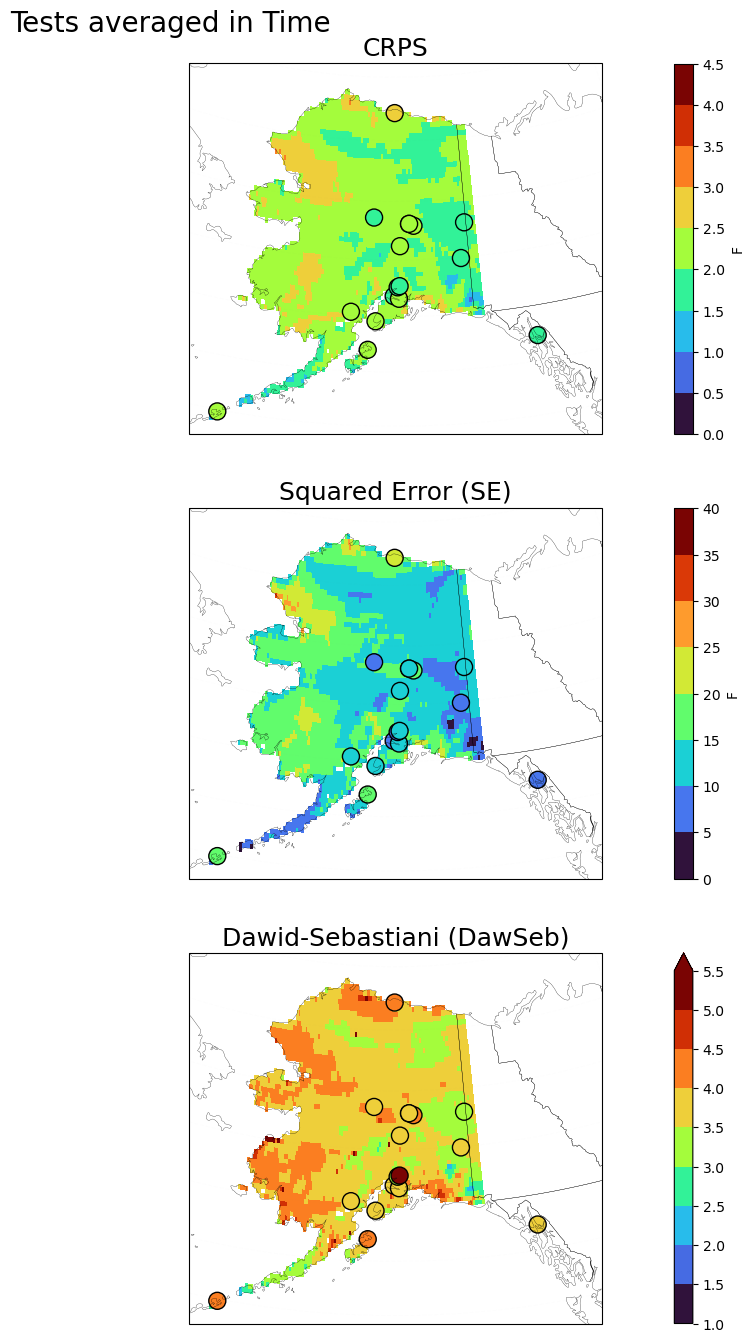

In [166]:
proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(18,18),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.95,hspace=0.2,wspace=0.02)

ax = ax.flatten()
clevs = np.arange(0,5,0.5)
cmap = cm.get_cmap('turbo',len(clevs)-1)
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)

cc = CRPS_cvERA5.mean('time').plot.pcolormesh(ax=ax[0],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],transform=ccrs.PlateCarree(),\
    cbar_kwargs={'label':units})
cc = ax[0].scatter(Tlon,Tlat,c=CRPS_cv.mean('time'),s=150,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),edgecolor='k')
ax[0].set_title(f'CRPS',fontsize=18)  

clevs = np.arange(0,45,5)
cmap = cm.get_cmap('turbo',len(clevs)-1)
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)
cc = SE_cvERA5.mean('time').plot.pcolormesh(ax=ax[1],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],transform=ccrs.PlateCarree(),\
    cbar_kwargs={'label':units})
cc = ax[1].scatter(Tlon,Tlat,c=SE_cv.mean('time'),s=150,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),edgecolor='k')
ax[1].set_title(f'Squared Error (SE)',fontsize=18)  

clevs = np.arange(1,6,0.5)
cmap = cm.get_cmap('turbo',len(clevs)-1)
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)
cc = DawSeb_cvERA5.mean('time').plot.pcolormesh(ax=ax[2],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],transform=ccrs.PlateCarree(),\
    cbar_kwargs={'label':''})
cc = ax[2].scatter(Tlon,Tlat,c=DawSeb_cv.mean('time'),s=150,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),edgecolor='k')
ax[2].set_title(f'Dawid-Sebastiani (DawSeb)',fontsize=18)  

for ix in range(0,len(ax)):
    ####
  ax[ix].set_extent((lon_min,lon_max,lat_min,lat_max), crs=proj_data)
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.2)

#

plt.suptitle(f'Tests averaged in Time',fontsize=20)  

*Time-averaged verification metrics for the nonstationary extreme value model across Alaska, comparing ERA5-derived estimates (shaded fields) with GHCND station observations (colored circles). The top panel shows the Continuous Ranked Probability Score (CRPS), the middle panel shows the Squared Error (SE), and the bottom panel shows the Dawid-Sebastiani Score (DawSeb). Lower values of each metric indicate better agreement between modeled and observed distributions. Spatial variations in the scores highlight regional differences in model performance, with generally lower errors and improved reliability along southern coastal regions and higher errors across parts of interior and northern Alaska. Station-based metrics provide an independent assessment of model skill at observation locations; see Technical details for scoring definitions.*

Text(0.5, 0.98, 'Tests averaged in Time')

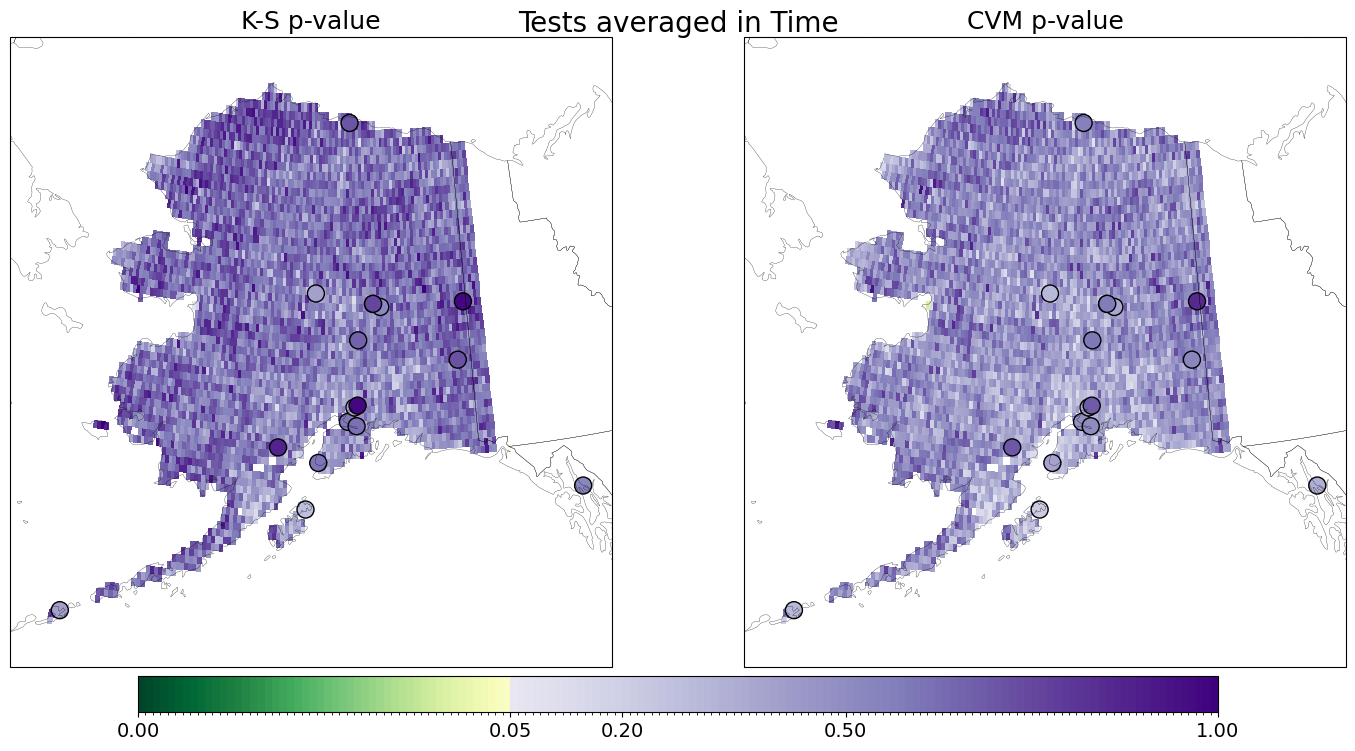

In [159]:
proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(18,9),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.95,hspace=0.04,wspace=0.04)
ax = ax.flatten()
cc = KS_pvalue_cvERA5.mean('time').plot.pcolormesh(ax=ax[0],cmap=cmap_pv,norm=norm_pv,transform=ccrs.PlateCarree(),add_colorbar=False)

cc = ax[0].scatter(Tlon,Tlat,c=KS_pvalue_cv.mean('time'),s=150,cmap=cmap_pv,norm=norm_pv,transform=ccrs.PlateCarree(),edgecolor='k')
ax[0].set_title(f'K-S p-value',fontsize=18)  
cc = CVM_pvalue_cvERA5.mean('time').plot.pcolormesh(ax=ax[1],cmap=cmap_pv,norm=norm_pv,transform=ccrs.PlateCarree(),add_colorbar=False)

cc = ax[1].scatter(Tlon,Tlat,c=CVM_pvalue_cv.mean('time'),s=150,cmap=cmap_pv,norm=norm_pv,transform=ccrs.PlateCarree(),edgecolor='k')
ax[1].set_title(f'CVM p-value',fontsize=18)  

for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.2)

ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=[0,0.05,0.2,0.5,1])
cbar.ax.tick_params(labelsize=14)   
#
plt.suptitle(f'Tests averaged in Time',fontsize=20)  

*Time-averaged goodness-of-fit test results for the fitted nonstationary extreme value model across Alaska. The left panel shows Kolmogorov-Smirnov (K-S) test p-values and the right panel shows Cramér-von Mises (CVM) test p-values. Shaded grid cells represent p-values computed from the ERA5 reanalysis, while circles indicate corresponding values at GHCND station locations. Higher p-values (purple shades) indicate stronger agreement between the fitted distribution and the observed data, whereas lower p-values (green shades) suggest a poorer fit. Across most of Alaska, p-values exceed the conventional significance threshold of 0.05, indicating that the fitted extreme value model provides an adequate representation of the observed climate extremes for both gridded and station-based datasets.*

In [160]:
Tquantile=['0.95','0.05']
vq=[float(x) for x in Tquantile]

In [161]:
clevs

array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5])

/var/folders/41/jpdddhvx1_bfhbywzg083cy00000gt/T/ipykernel_90601/2673738305.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlBu_r',len(clevs))


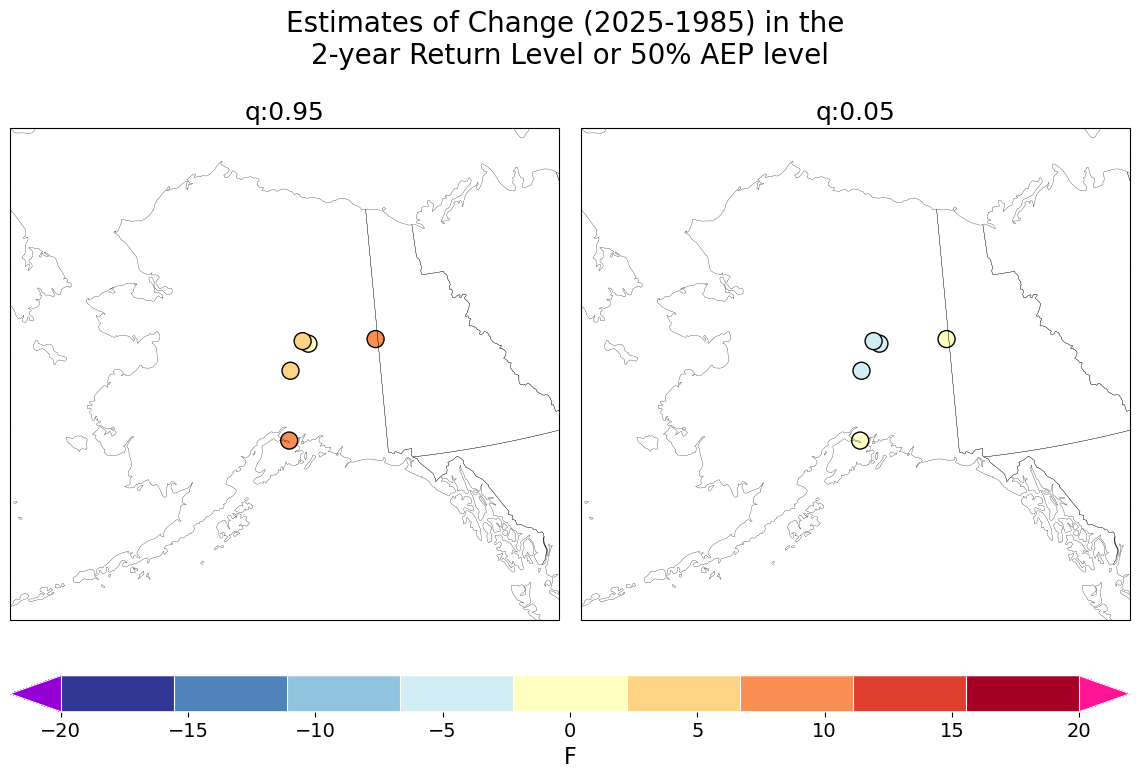

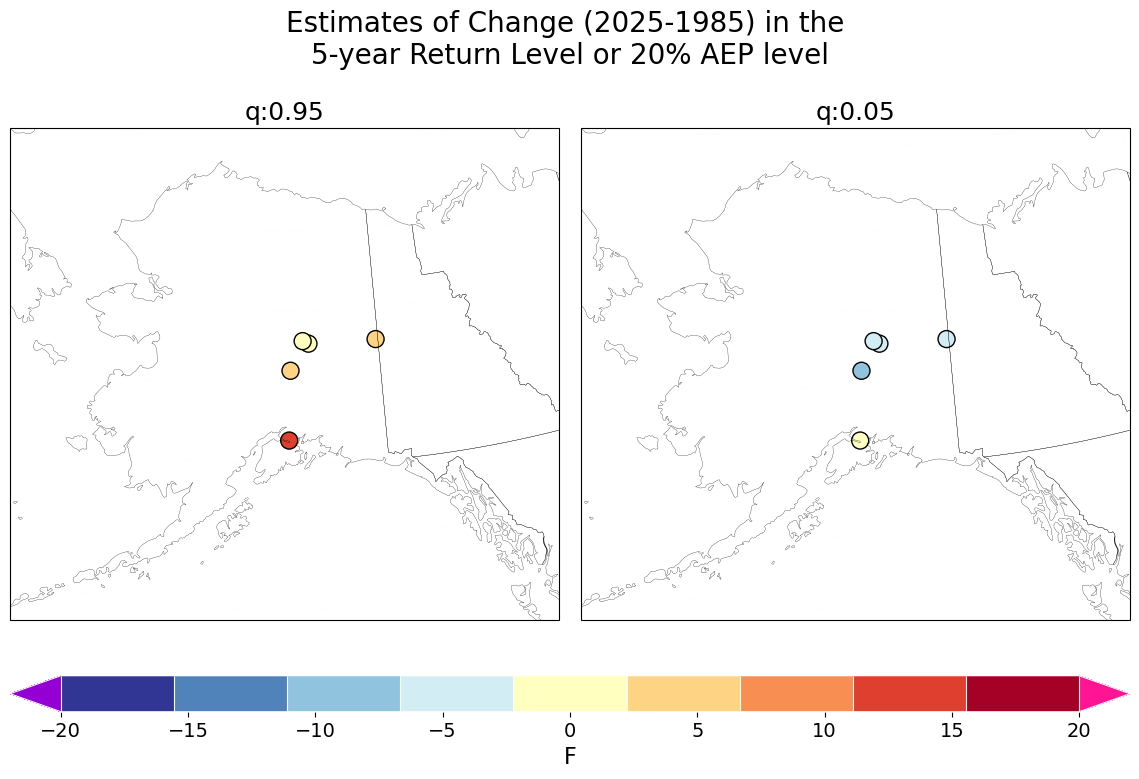

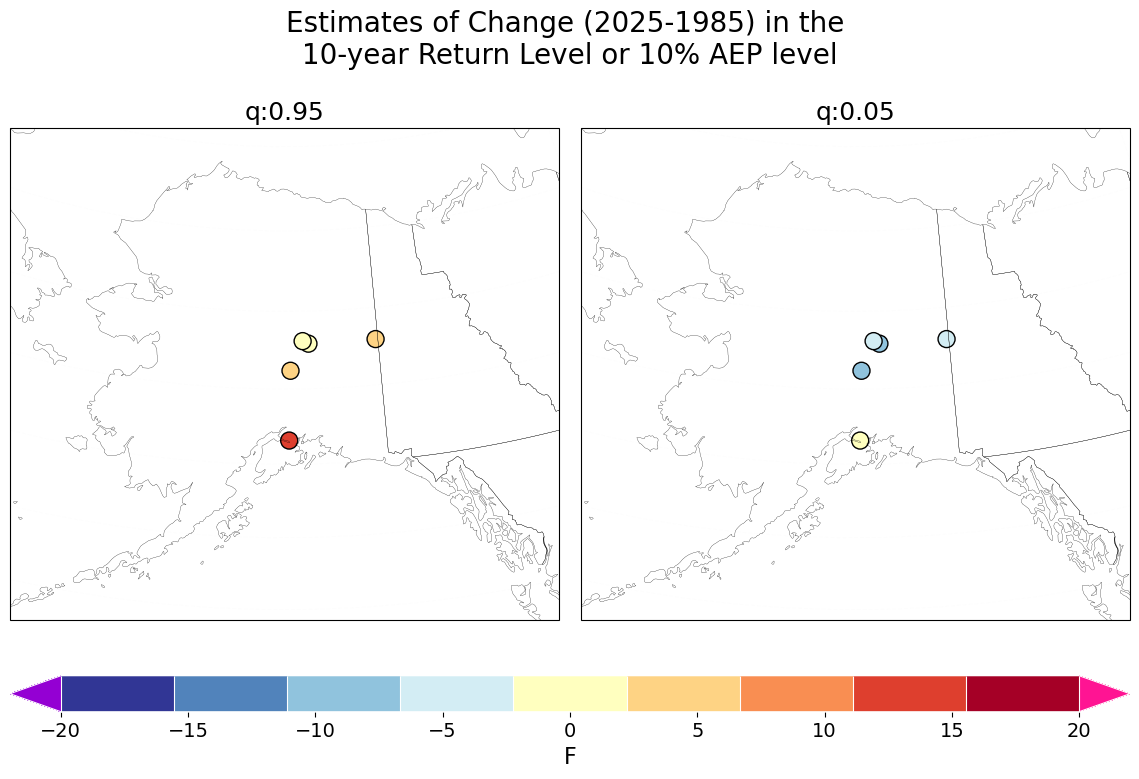

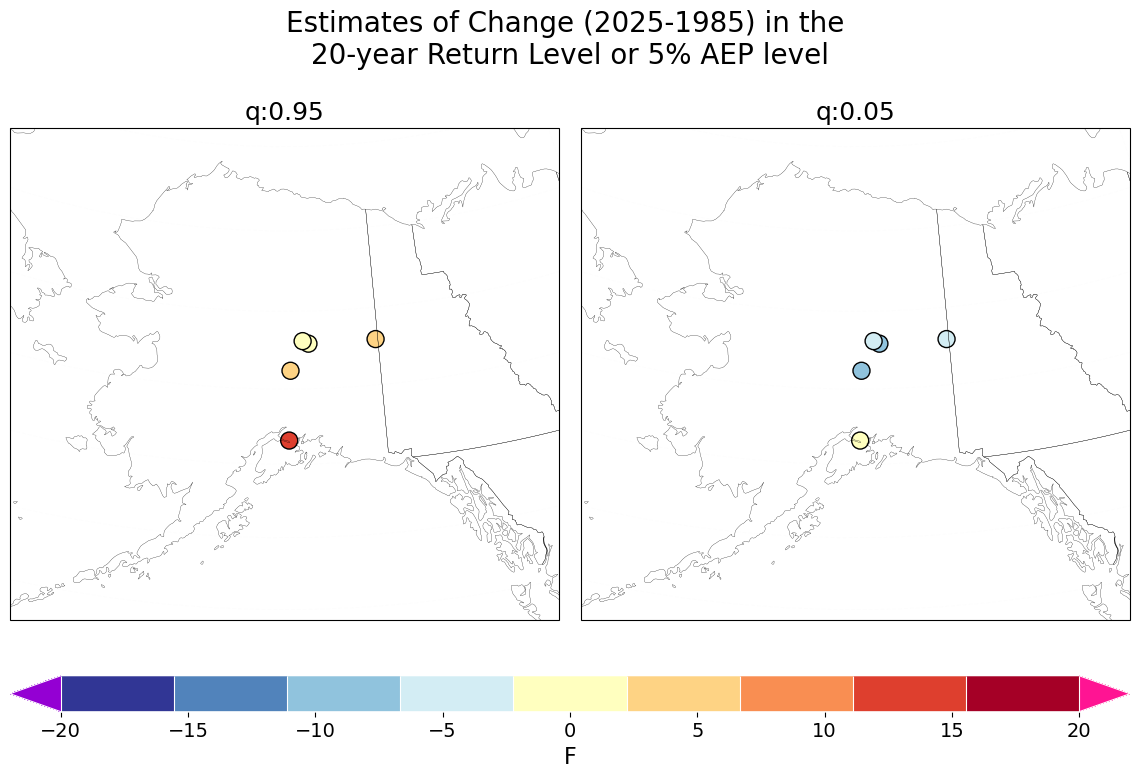

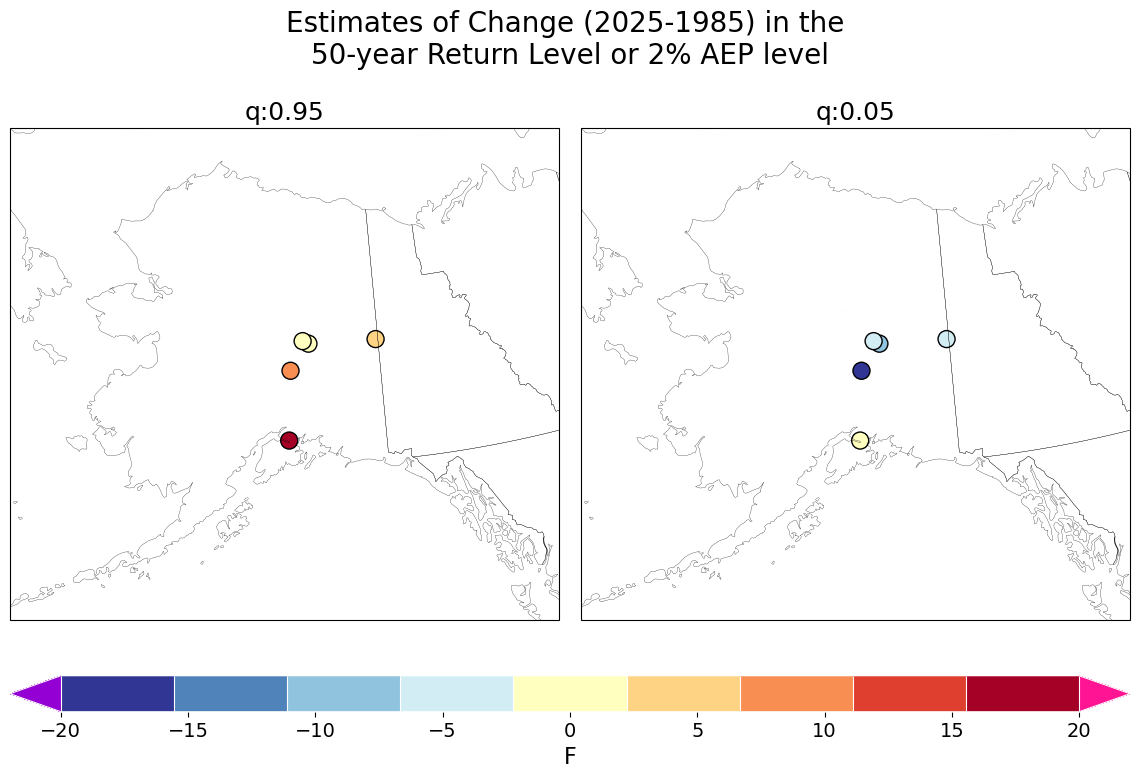

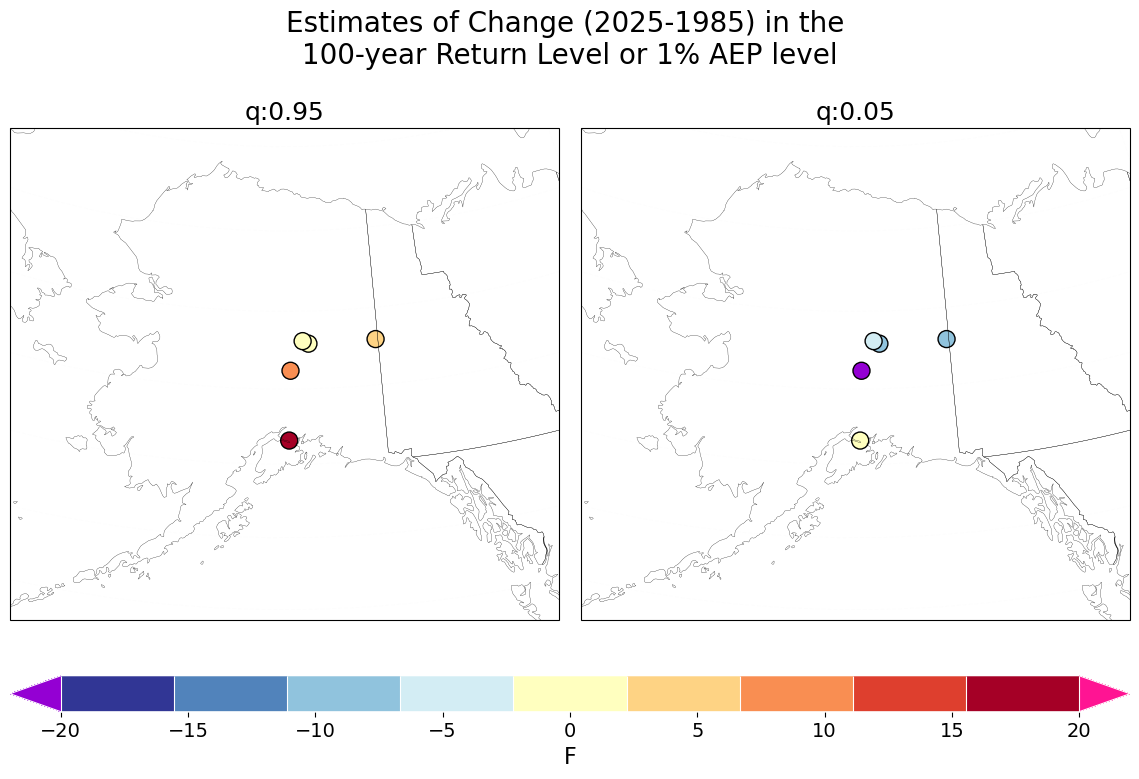

In [ ]:
proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

clevs=np.arange(-20,25,5)
cmap = cm.get_cmap('RdYlBu_r',len(clevs))
cmap.set_under('darkviolet')
cmap.set_over('deeppink')
norm = mcolors.TwoSlopeNorm(vcenter=0,vmin=clevs[0],vmax=-clevs[0])

for irp in range(0,len(return_periods)):
  fig, ax = plt.subplots(nrows=1,ncols=len(Tquantile),figsize=(14,9),subplot_kw={'projection':proj})
  plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)

  for ix in range(0,len(Tquantile)):
    xxx = xr.where(np.isnan(dsI['TXx'].sel(time=2025))==False,Diffrl_q.sel(quantile=vq[ix]).isel(return_periods=irp),np.nan) 
    lon = longitude.sel(station=xxx.dropna(dim='station').station).data
    lat = latitude.sel(station=xxx.dropna(dim='station').station).data
    #cc = Diffrl_qERA5.sel(quantile=vq[ix]).isel(return_periods=irp).plot.pcolormesh\
    #(ax=ax[ix],transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,add_colorbar=False)
    cc = ax[ix].scatter(lon,lat,c=xxx.dropna(dim='station'),s=150,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),edgecolor='k')

    ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
    ##

    ####
    grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
    grd.top_labels = False   # Disable top labels
    grd.right_labels = False # Disable right labels. 
    ax[ix].set_extent((lon_min,lon_max,lat_min,lat_max), crs=proj_data)
    ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.2)

  #
  ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
  cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',extend='both',norm=norm,drawedges=True)
  cbar.set_ticks(clevs[:])
  cbar.ax.tick_params(labelsize=14)  
  cbar.set_label(label=f'{units}',fontsize=16)
  cbar.outline.set_edgecolor('w')
  cbar.dividers.set_edgecolor('w')
  cbar.dividers.set_linewidth(0.8)

  plt.suptitle(f'Estimates of Change ({Tyear[-1]}-{Tyear[0]}) in the \n{return_periods[irp]}-year Return Level or {AEP[irp]*100:.0f}% AEP level',fontsize=20)  

*Estimated change in the return level / annual exceedance probability for different return periods between 2025 and 1985 across Alaska, expressed as 2025 minus 1985 (F). The left panel shows the 95th percentile (q = 0.95) of the estimated change and the right panel shows the 5th percentile (q = 0.05). Shaded grid cells represent estimates derived from the ERA5 reanalysis, while circles indicate corresponding changes estimated from GHCND station observations. Negative values (yellow to red shades) indicate decreases in the magnitude of rare extreme events, whereas positive values (blue shades) indicate increases.*

proj = ccrs.LambertConformal(central_latitude=cLat, central_longitude=cLon)
proj_data = ccrs.PlateCarree()

clevs=np.arange(0,7000,500)
cmap = cm.get_cmap('turbo',len(clevs))
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)

for irp in range(0,len(return_periods)):
  fig, ax = plt.subplots(nrows=2,ncols=len(Tquantile),figsize=(14,11),subplot_kw={'projection':proj})
  plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)
  ax = ax.flatten()
  for ix in range(0,len(Tquantile)):
    iyear = Tyears[0]
    xxx = xr.where(np.isnan(dsI['AFI'].sel(time=iyear))==False,rl_q.sel(time=iyear,quantile=vq[ix]).isel(return_periods=irp),np.nan) 
    lon = longitude.sel(station=xxx.dropna(dim='station').station).data
    lat = latitude.sel(station=xxx.dropna(dim='station').station).data
    #cc = rl_qERA5.sel(time=iyear,quantile=vq[ix]).isel(return_periods=irp).plot.pcolormesh\
    #    (ax=ax[ix],transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,add_colorbar=False)
    cc = ax[ix].scatter(lon,lat,c=xxx.dropna(dim='station'),s=150,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),edgecolor='k')

    ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   

    iyear = Tyears[1]
    xxx = xr.where(np.isnan(dsI['AFI'].sel(time=iyear))==False,rl_q.sel(time=iyear,quantile=vq[ix]).isel(return_periods=irp),np.nan) 
    lon = longitude.sel(station=xxx.dropna(dim='station').station).data
    lat = latitude.sel(station=xxx.dropna(dim='station').station).data
    #cc = rl_qERA5.sel(time=iyear,quantile=vq[ix]).isel(return_periods=irp).plot.pcolormesh\
    #    (ax=ax[ix+2],transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,add_colorbar=False)
    cc = ax[ix+2].scatter(lon,lat,c=xxx.dropna(dim='station'),s=150,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),edgecolor='k')
    ax[ix+2].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
    ##
    ####
  for ix in range(0,len(ax)):

    grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
    grd.top_labels = False   # Disable top labels
    grd.right_labels = False # Disable right labels. 
    ax[ix].set_extent((lon_min,lon_max,lat_min,lat_max), crs=proj_data)
    ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.2)
  ax[0].text(1.2,1.1,f'{Tyears[0]}',transform=ax[0].transAxes,fontsize=24)
  ax[2].text(1.2,1.1,f'{Tyears[1]}',transform=ax[2].transAxes,fontsize=24)
  #
  ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
  cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal', drawedges=True)
  cbar.set_ticks(clevs[::2])
  cbar.ax.tick_params(labelsize=14)  
  cbar.set_label(label=f'{units}',fontsize=16)
  cbar.outline.set_edgecolor('w')
  cbar.dividers.set_edgecolor('w')
  cbar.dividers.set_linewidth(0.8)

  plt.suptitle(f'Estimates in the {return_periods[irp]}-year Return Level or {AEP[irp]*100:.0f}% AEP',fontsize=20)  

*Spatial distribution of the estimated return level /(annual exceedance probability, AEP) for several return periods of the Air Freezing Index (AFI; °C-days) across Alaska from ERA5, for 1985 (top row) and 2025 (bottom row). The left column shows the 0.95 quantile (upper estimate) and the right column the 0.05 quantile (lower estimate) of the return-level distribution. Colored shading represents ERA5 reanalyse-based estimates, while circles indicate corresponding estimates derived from GHCND station observations. Higher AFI return levels occur in northern Alaska, exceeding 5,000–6,000 °C-days, whereas lower values are observed along the southern and coastal regions. Comparison between ERA5 and GHCND estimates demonstrates the ability of the reanalysis to reproduce the spatial gradient and magnitude of observed AFI extremes while highlighting site-specific differences at individual stations. The maps also illustrate projected changes in AFI extreme return levels between 1985 and 2025, with generally lower values in 2025, consistent with a reduction in winter freezing severity across much of Alaska.*

## Step 4: Technical notes

### Scoring formulas

- CRPS for predictive CDF $F$ and observation $y$:

  $$\mathrm{CRPS}(F,y)=\int_{-\infty}^{\infty}(F(x)-\mathbf{1}_{\{x\ge y\}})^2\,dx.$$

- Squared Error (SE):

  $$\mathrm{SE}=(y-\mu)^2.$$

  y: observation

  μ: predictive mean


- Dawid–Sebastiani Score (DSS): 

  $$\mathrm{DSS}=\frac{(y-\mu)^2}{\sigma^2}+2\log\sigma.$$

  y: observation

  μ: predictive mean

  σ: predictive standard deviation
